# LangGraph 핸즈온 — 평균회귀 트레이딩 에이전트

> **AI 오딧세이 세미나 · "노드·엣지·State 편"** 의 실습 노트북 (퀀트 버전).
> 리포트의 5단계 설계를 **위에서 아래로 실행**하며 하나의 트레이딩 에이전트를 완성합니다.

이 노트북은 리포트 본문(서사)과 `scripts/` 의 코드(실행)를 한곳에 합친 것입니다. 각 셀은 리포트의 한 절에 대응합니다.

| 단계 | 리포트 | 이 노트북에서 |
|---|---|---|
| ① 분해 | §2 | 업무(평균회귀 매매)를 노드로 쪼개고 최소 그래프를 돌린다 |
| ② 스텝 유형 | §2.2 | 네 가지 작업 유형으로 분류 (LLM·데이터·액션·사용자입력) |
| ③ State 설계 | §3.1-3.2 | `TradingAgentState` — raw 데이터(가격·신호)만, 포맷은 노드에서 |
| ④ 노드 구현 + 에러 | §3.3-3.4 | 7개 노드 + 에러 4전략 |
| ⑤ 연결 + 사람 개입 | §4 | `Command(goto)` 라우팅 · `interrupt`/resume · checkpointer |

> **API 키 없이 돌아갑니다.** `OPENAI_API_KEY` 가 있으면 신호 근거를 실제 LLM(`gpt-5-nano`)이 설명하고, 없으면 z-score 규칙만으로 동작합니다. 방향(롱/숏)은 **언제나 결정론적 z-score** 가 정합니다.

> ⚠️ **교육용 예제입니다.** 실제 매매·브로커 연동이 아니라 dry-run 으로 LangGraph 흐름만 보여 줍니다.

## 0. 준비 — 패키지와 LLM 옵셔널 헬퍼

먼저 의존성을 확인합니다. 이미 설치돼 있으면 아래 설치 셀은 건너뛰어도 됩니다. 그다음, 신호 근거 설명을 **키가 있으면 실제 LLM, 없으면 규칙 문구**로 처리하는 헬퍼를 정의합니다. 이 패턴 덕분에 세미나에서 키 없이도 모든 셀이 실행됩니다.

In [1]:
# 필요시 설치 (이미 깔려 있으면 satisfied 로 건너뜀)
%pip install -q "langgraph>=1.0" langchain-openai python-dotenv


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import statistics
from typing import Literal, TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import Command, RetryPolicy, interrupt

# .env 가 있으면 로드 (없어도 무방)
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass


def get_llm():
    """OPENAI_API_KEY 가 있고 패키지가 깔려 있으면 ChatOpenAI, 아니면 None."""
    if not os.getenv("OPENAI_API_KEY"):
        return None
    try:
        from langchain_openai import ChatOpenAI
        return ChatOpenAI(model="gpt-5-nano")  # 리포트가 쓴 모델
    except ImportError:
        return None


_mode = "실제 LLM (rationale 생성)" if get_llm() is not None else "z-score 규칙만 (OPENAI_API_KEY 없음)"
print(f"신호 모드: {_mode}")

신호 모드: z-score 규칙만 (OPENAI_API_KEY 없음)


## 1. 분해 + 스텝 유형 — 업무를 노드로 쪼갠다 (§2)

LangGraph 설계의 첫걸음은 업무를 **개별 스텝(노드)** 으로 나누는 것입니다. 노드 하나는 "한 가지 일만 하는 함수"이고, 각 노드는 네 가지 **스텝 유형** 중 하나입니다 — 🧠 LLM/계산(신호·사이징), 🗄️ 데이터(시세·리스크 조회), ⚡ 액션(주문 전송·이상 기록), 👤 사용자 입력(주문 승인). 트레이딩 에이전트는 7개 노드로 분해됩니다: `fetch_market_data → generate_signal → {check_risk · flag_anomaly} → size_position → approve_order → place_order`.

아래 그림에서 **색 = 스텝 유형**(🟦 LLM·계산 · 🟩 데이터 · 🟥 액션 · 🟨 사용자 입력), **실선 = 고정 엣지 3개**(`add_edge`), **점선 = 노드 안 `Command(goto=...)` 라우팅** 입니다. 라우팅 규칙은 §3에서 코드로 봅니다.

```mermaid
flowchart TD
    START([START]) --> FMD["📈 fetch_market_data<br/>🗄️ 데이터"]
    FMD --> GS["🧮 generate_signal<br/>🧠 LLM·계산"]
    GS -.->|데이터 이상| FA["⚠️ flag_anomaly<br/>⚡ 액션"]
    GS -.->|flat · 무거래| E1([END])
    GS -.->|진입 신호| CR["🛡️ check_risk<br/>🗄️ 데이터·계산"]
    CR -.->|한도 OK| SP["📐 size_position<br/>🧠 계산"]
    CR -.->|캡 초과 · 차단| AO["👤 approve_order<br/>👤 사용자 입력"]
    SP -.-> AO
    AO -.->|승인| PO["📤 place_order<br/>⚡ 액션"]
    AO -.->|거부 · 보류| E2([END])
    PO --> E3([END])
    FA -.-> E4([END])

    classDef llm fill:#EEF2FF,stroke:#6366F1,color:#1E1B4B;
    classDef data fill:#ECFDF5,stroke:#10B981,color:#064E3B;
    classDef action fill:#FEF2F2,stroke:#EF4444,color:#7F1D1D;
    classDef human fill:#FFFBEB,stroke:#F59E0B,color:#78350F;
    class GS,SP llm;
    class FMD,CR data;
    class FA,PO action;
    class AO human;
```


## 2. State 설계 — raw 데이터만 담는다 (§3.1-3.2)

State 는 모든 노드가 공유하는 **메모리**입니다. 담을지 말지는 한 가지 질문으로 정합니다 — *"단계를 넘어 보존돼야 하는가?"* 핵심 원칙은 **포맷된 문자열이 아니라 raw 데이터(가격 윈도우·신호 dict)를 저장**하는 것입니다. 그래야 노드마다 같은 데이터를 다르게 포맷해 쓰고, 프롬프트를 바꿔도 스키마가 흔들리지 않습니다. `total=False` 로 둬서 초기 State 에 모든 키를 채우지 않아도 되게 합니다(리포트 §3.4 의 주의).

아래는 각 필드를 **누가 쓰고 누가 읽는지** 의 흐름입니다 — 전부 raw 값이라 노드마다 다르게 포맷해 씁니다.

| 필드 | 저장 이유 | 쓰는 노드 | 읽는 노드 |
|---|---|---|---|
| `instrument` · `price_window` · `headline` | 시세 재요청이 비쌈 | (초기 입력) | generate_signal · check_risk · size_position |
| `signal` | 이후 여러 노드가 사용 | generate_signal | size_position · approve_order |
| `risk_report` | 재계산 비쌈 | check_risk | size_position |
| `order` | 주문 후보 | size_position | approve_order · place_order |
| `approval_required` | 사람 검토 플래그 | generate_signal · check_risk | approve_order |
| `log` | 관찰·디버깅 | 모든 노드 | 최종 출력 |


In [3]:
class SignalDecision(TypedDict):
    """평균회귀 신호 — z-score 가 준 그대로 '하나의 딕셔너리' 로 저장."""
    direction: Literal["long", "short", "flat", "uncertain"]
    conviction: Literal["low", "medium", "high", "critical"]  # critical = '사람 검토 필요'
    instrument: str
    rationale: str


class TradingAgentState(TypedDict, total=False):
    # 원본 시장 데이터 (다시 가져오기 비쌈 → 담는다)
    instrument: str
    price_window: list[float]
    market_data_timestamp: str
    headline: str | None
    # 신호 (이후 여러 노드가 사용)
    signal: SignalDecision | None
    # 리스크 점검 결과 (다시 계산 비쌈)
    risk_report: dict | None
    # 주문 후보
    order: dict | None
    approval_required: bool
    # 실행 로그 (관찰·디버깅용)
    log: list[str]


def log(state, line):
    """누적 로그 헬퍼 — log 에 한 줄 덧붙인 새 리스트를 돌려준다."""
    return [*state.get("log", []), line]


# 신호 임계값(본문에 못 박는 규칙) · z 단위
ENTRY_Z, EXIT_Z, HIGH_Z, CRITICAL_Z = 1.0, 0.5, 1.5, 2.5
VOL_CAP, EQUITY, TARGET_FRACTION = 0.06, 100_000.0, 0.02

print("State 스키마 정의 완료:", list(TradingAgentState.__annotations__))

State 스키마 정의 완료: ['instrument', 'price_window', 'market_data_timestamp', 'headline', 'signal', 'risk_report', 'order', 'approval_required', 'log']


## 3. 노드 구현 + 에러 4전략 — 라우팅은 노드 안에서 (§3.3-3.4)

노드는 **State 를 받아 업데이트를 돌려주는 함수**입니다. 분기가 필요한 노드는 `Command(goto=...)` 로 **다음 행선지까지 스스로 결정**하고, `Command[Literal[...]]` 타입 힌트로 갈 수 있는 곳을 선언합니다. 에러는 종류마다 다르게 다룹니다 — 아래 코드에 네 전략이 들어 있습니다: ① `fetch_market_data` 에 거는 `RetryPolicy`(재시도), ③ `approve_order` 의 `interrupt()`(일시정지), ④ `place_order` 의 `raise`(띄워보내기). ②(LLM 복구·되돌아오기)는 도구 루프 패턴이라 §3.3 끝의 별도 데모에서 봅니다.

라우팅 규칙: `generate_signal` 은 z-score 로 방향을 정해 — 데이터 이상이면 `flag_anomaly`, 평탄이면 무거래(END), 진입 신호면 `check_risk` 로 갑니다. `conviction==critical`(비정상적으로 강한 신호)이면 곧장 사람에게 보내지 않고 **`approval_required` 플래그만** 세운 뒤 정상 경로(리스크→사이징→승인)를 탑니다.

**에러 4전략** 한눈에 — 종류마다 다루는 법이 다릅니다:

| # | 전략 | 트리거 | 메커니즘 | 위치 |
|---|---|---|---|---|
| ① | 재시도 | 일시적 오류(레이트리밋·네트워크) | `RetryPolicy(max_attempts=3)` | `fetch_market_data` |
| ② | 되돌아오기 | 복구 가능한 도구·LLM 실패 | 에러를 State 에 담아 `agent` 로 loop-back | 도구 루프 데모 |
| ③ | 일시정지 | 사람 판단 필요 | `interrupt()` → checkpointer 저장 | `approve_order` |
| ④ | 띄워보내기 | 복구 불가·예상 못한 오류 | `raise` 로 그래프 중단 | `place_order` |


In [4]:
def _zscore(w):
    return (w[-1] - statistics.fmean(w)) / statistics.pstdev(w)


def _rationale(state, direction, z):
    """신호 근거 한 줄. LLM 이 있으면 헤드라인까지 엮고, 없으면 규칙 문구."""
    llm = get_llm()
    if llm is not None:
        prompt = (f"아래 평균회귀 신호를 한국어 한 문장으로 설명하라(방향은 바꾸지 말 것).\n"
                  f"종목 {state['instrument']} 방향 {direction} z={z:.2f} "
                  f"헤드라인 {state.get('headline') or '(없음)'}")
        return llm.invoke(prompt).content.strip()
    return f"z={z:.2f} → 평균에서 {'아래' if z < 0 else '위'}로 벗어나 {direction} 되돌림 기대"


def fetch_market_data(state) -> dict:
    """[데이터 스텝] 시세 수신. 늘 generate_signal 로 간다(고정 엣지). RetryPolicy 대상(전략 ①)."""
    return {"log": log(state, f"📈 fetch_market_data: {state['instrument']} 종가 {len(state['price_window'])}개")}


def generate_signal(state) -> Command[Literal["check_risk", "flag_anomaly", END]]:
    """[LLM/계산 스텝] z-score 로 방향·확신을 정하고 라우팅. 방향은 결정론적, LLM 은 근거만."""
    w = state.get("price_window") or []
    bad = (len(w) < 10) or any((x != x) or x <= 0 for x in w)
    if bad or statistics.pstdev(w) == 0:
        sig = {"direction": "uncertain", "conviction": "low", "instrument": state["instrument"],
               "rationale": "가격 데이터 품질 이상"}
        return Command(update={"signal": sig, "log": log(state, "🧮 generate_signal: 데이터 이상 → flag_anomaly")},
                       goto="flag_anomaly")
    z = _zscore(w)
    direction = "long" if z <= -ENTRY_Z else "short" if z >= ENTRY_Z else "flat"
    az = abs(z)
    conviction = ("critical" if az >= CRITICAL_Z else "high" if az >= HIGH_Z
                  else "medium" if az >= ENTRY_Z else "low")
    sig = {"direction": direction, "conviction": conviction, "instrument": state["instrument"],
           "rationale": _rationale(state, direction, z)}
    if direction == "flat":
        return Command(update={"signal": sig, "log": log(state, f"🧮 generate_signal: z={z:.2f} flat → 무거래(END)")},
                       goto=END)
    approval = conviction == "critical"  # 큰 신호는 사람 검토 필요(직행 아님)
    line = f"🧮 generate_signal: z={z:.2f} {direction} conviction={conviction} → check_risk"
    return Command(update={"signal": sig, "approval_required": approval, "log": log(state, line)}, goto="check_risk")


def check_risk(state) -> Command[Literal["size_position", "approve_order"]]:
    """[데이터+계산 스텝] 변동성·노출을 읽어 한도 계산. 캡 초과면 차단→approve_order 에스컬레이션."""
    w = state["price_window"]
    vol = statistics.pstdev(w) / statistics.fmean(w)
    blocked = vol > VOL_CAP
    max_notional = round(min(EQUITY * 0.05, EQUITY * 0.05 * (VOL_CAP / max(vol, 1e-9))), 2)
    report = {"volatility": round(vol, 4), "max_allowed_notional": max_notional, "blocked": blocked}
    if blocked:
        return Command(update={"risk_report": report, "approval_required": True,
                               "log": log(state, f"🛡️ check_risk: 변동성 {vol:.1%} 초과 → 차단 에스컬레이션")},
                       goto="approve_order")
    return Command(update={"risk_report": report,
                           "log": log(state, f"🛡️ check_risk: 변동성 {vol:.1%} OK · 한도 ${max_notional:,.0f}")},
                   goto="size_position")


def size_position(state) -> Command[Literal["approve_order"]]:
    """[계산 스텝] 한도 안에서 고정비중 주문 생성. (풀 켈리 회피)"""
    sig, report = state["signal"], state.get("risk_report") or {}
    last = state["price_window"][-1]
    notional = min(EQUITY * TARGET_FRACTION, report.get("max_allowed_notional", EQUITY))
    qty = int(notional // last)
    side = "buy" if sig["direction"] == "long" else "sell"
    order = {"side": side, "qty": qty, "notional": round(qty * last, 2), "limit_price": last, "type": "limit"}
    return Command(update={"order": order,
                           "log": log(state, f"📐 size_position: {side} {qty}주 @ ${last:,.2f}")},
                   goto="approve_order")


def approve_order(state) -> Command[Literal["place_order", END]]:
    """[사용자 입력 스텝] interrupt 로 멈추고 주문 승인을 받는다(전략 ③). 브로커 호출 이전에 멈춘다."""
    order, sig = state.get("order"), state.get("signal") or {}
    human_decision = interrupt({
        "instrument": state.get("instrument", ""),
        "order": order,  # 차단 에스컬레이션이면 None
        "conviction": sig.get("conviction"),
        "approval_required": state.get("approval_required", False),
        "action": "이 주문을 승인/거부/수정하세요",
    })
    if human_decision.get("approved") and order is not None:
        edited = human_decision.get("edited_qty")
        if edited is not None:
            order = {**order, "qty": edited, "notional": round(edited * order["limit_price"], 2)}
        return Command(update={"order": order, "log": log(state, "👤 approve_order: 승인 → 발주")}, goto="place_order")
    return Command(update={"log": log(state, "👤 approve_order: 거부/보류 → 미발주")}, goto=END)


def place_order(state) -> dict:
    """[액션 스텝] 브로커 전송(dry-run). 예상 못한 오류는 그대로 띄워보낸다(전략 ④)."""
    o = state["order"]
    try:
        return {"log": log(state, f"📤 place_order: dry-run 발주 {o['side']} {o['qty']}주 @ ${o['limit_price']:,.2f}")}
    except Exception:
        raise


def flag_anomaly(state) -> Command[Literal[END]]:
    """[액션 스텝] 데이터 이상 기록 후 무거래."""
    return Command(update={"log": log(state, f"⚠️ flag_anomaly: {state['instrument']} 데이터 이상 → 무거래")}, goto=END)

print("노드 7개 정의 완료")

노드 7개 정의 완료


### 에러 전략 ① 재시도 · ② 되돌아오기 — 동작 확인

위 노드들에 ③·④ 가 들어 있으니, 나머지 두 전략을 작은 그래프로 직접 돌려 봅니다. **①** 은 `RetryPolicy` 가 일시적 시세 호출 실패를 자동 재시도하는 모습을, **②** 는 지표 계산 도구 실패 시 에러를 State 에 담아 `agent` 로 되돌아가 재계획하는 loop-back 패턴을 보여 줍니다.

두 전략의 차이는 **루프가 어디서 도느냐** 입니다 — ①은 같은 노드를 그 자리에서 재실행(점선 자기루프), ②는 실제 엣지를 타고 `agent` 로 돌아갑니다(실선 loop-back).

```mermaid
flowchart LR
    subgraph S1["① 재시도 — 같은 노드 재실행"]
        direction LR
        F["fetch"] -. "시도1·2 실패" .-> F
        F -->|"시도3 성공"| OK1([END])
    end
    subgraph S2["② 되돌아오기 — loop-back 엣지"]
        direction LR
        A["agent"] --> R["run_indicator"]
        R -->|"실패 → 에러를 State 에"| A
        A -->|"재계획 후 성공 · done"| OK2([END])
    end
```


In [5]:
# ① 일시적 오류 — 두 번 실패 후 세 번째 성공 (RetryPolicy 가 실제로 재시도)
_attempts = []
def flaky_fetch(state: dict) -> dict:
    _attempts.append(1); n = len(_attempts)
    if n < 3:
        print(f"  📈 시세 호출 시도 {n}: 일시적 실패(레이트리밋) → 재시도"); raise ConnectionError("rate limited")
    print(f"  📈 시세 호출 시도 {n}: 성공 ✅"); return {"price_window": [150, 151, 149, 145]}

g1 = StateGraph(dict)
g1.add_node("fetch", flaky_fetch, retry_policy=RetryPolicy(max_attempts=3, initial_interval=0.01, retry_on=(ConnectionError,)))
g1.add_edge(START, "fetch"); g1.add_edge("fetch", END)
print("① 재시도 정책:"); g1.compile().invoke({})

# ② LLM 복구 가능 — 에러를 State 에 담아 agent 로 되돌아오기(loop-back)
class LoopState(TypedDict, total=False):
    tries: int; tool_error: str; done: bool

def agent(state: LoopState) -> Command[Literal["run_indicator", END]]:
    if state.get("done"): return Command(goto=END)
    if state.get("tool_error"):
        print(f"  🧠 agent: 직전 에러 '{state['tool_error']}' 보고 다른 파라미터로 재계획")
    return Command(goto="run_indicator")

def run_indicator(state: LoopState) -> Command[Literal["agent"]]:
    tries = state.get("tries", 0) + 1
    if tries == 1:
        print("  ⚙️ run_indicator: 룩백 부족으로 실패 → 에러 저장 후 agent 로")
        return Command(update={"tries": tries, "tool_error": "lookback too short"}, goto="agent")
    print("  ⚙️ run_indicator: 성공 ✅")
    return Command(update={"tries": tries, "tool_error": "", "done": True}, goto="agent")

g2 = StateGraph(LoopState)
g2.add_node("agent", agent); g2.add_node("run_indicator", run_indicator)
g2.add_edge(START, "agent")
print("\n② 되돌아오기(loop-back):"); g2.compile().invoke({})
print()

① 재시도 정책:
  📈 시세 호출 시도 1: 일시적 실패(레이트리밋) → 재시도
  📈 시세 호출 시도 2: 일시적 실패(레이트리밋) → 재시도
  📈 시세 호출 시도 3: 성공 ✅

② 되돌아오기(loop-back):
  ⚙️ run_indicator: 룩백 부족으로 실패 → 에러 저장 후 agent 로
  🧠 agent: 직전 에러 'lookback too short' 보고 다른 파라미터로 재계획
  ⚙️ run_indicator: 성공 ✅



## 4. 노드를 그래프로 연결 — 엣지는 최소, checkpointer 와 함께 (§4.2)

노드들이 스스로 라우팅하므로(`Command(goto=...)`) 필요한 고정 엣지는 셋뿐입니다. `interrupt()` 로 사람 승인을 쓰려면 상태를 저장할 **checkpointer** 와 함께 컴파일해야 합니다.

In [6]:
def build_graph(checkpointer=None):
    workflow = StateGraph(TradingAgentState)
    workflow.add_node("fetch_market_data", fetch_market_data,
                      retry_policy=RetryPolicy(max_attempts=3, initial_interval=1.0))  # 전략 ①
    workflow.add_node("generate_signal", generate_signal)
    workflow.add_node("check_risk", check_risk)
    workflow.add_node("size_position", size_position)
    workflow.add_node("approve_order", approve_order)
    workflow.add_node("place_order", place_order)
    workflow.add_node("flag_anomaly", flag_anomaly)
    # 고정 엣지는 셋뿐 — 나머지 라우팅은 노드 안 Command 가 한다
    workflow.add_edge(START, "fetch_market_data")
    workflow.add_edge("fetch_market_data", "generate_signal")
    workflow.add_edge("place_order", END)
    return workflow.compile(checkpointer=checkpointer)

graph = build_graph()
print("그래프 컴파일 완료 · 노드:", list(graph.get_graph().nodes)[1:-1])

그래프 컴파일 완료 · 노드: ['fetch_market_data', 'generate_signal', 'check_risk', 'size_position', 'approve_order', 'place_order', 'flag_anomaly']


### 그래프 구조 시각화

`Command(goto)` 라우팅은 그래프에서 **점선**으로, `add_edge` 로 박은 고정 엣지는 **실선**으로 보입니다. 리포트 fig03 의 "실선=고정 엣지, 점선=노드 안 분기" 와 같은 그림입니다.

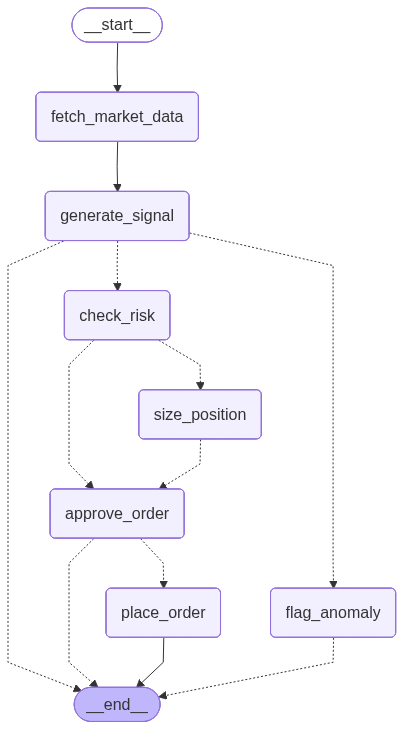

In [7]:
from IPython.display import Image, display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # 네트워크/graphviz 없으면 Mermaid 텍스트로 폴백
    print(graph.get_graph().draw_mermaid())

## 5. 멈췄다가 재개 — interrupt → checkpointer → resume (§4.3)

이제 완성된 그래프를 실제로 돌립니다. `interrupt()` 를 만나면 그래프는 모든 State 를 checkpointer 에 저장하고 **주문 전송 직전** 멈춥니다. 같은 `thread_id` 로 `Command(resume=...)` 를 호출하면 **멈춘 지점부터** 이어집니다. 두 시나리오로 — 정상 발주(승인)와 critical 에스컬레이션(수량 축소 승인) — 을 봅니다.

아래 시퀀스가 그 생명주기입니다 — 멈춤·저장·재개가 한 번에 보입니다.

```mermaid
sequenceDiagram
    participant U as 👤 사람
    participant G as 그래프
    participant C as 💾 checkpointer
    G->>G: fetch → signal → risk → size → approve_order 도달
    G->>C: interrupt() · 전체 State 저장
    G-->>U: ⏸️ 일시정지 (주문 후보 · conviction)
    Note over G,C: 주문 전송 직전 멈춤 · 프로세스 꺼져도 안전
    U->>G: Command(resume={approved, edited_qty})
    C->>G: 같은 thread_id 로 State 복원
    G->>G: 멈춘 지점부터 place_order 계속
    G-->>U: 📜 실행 로그
```


In [8]:
_MARKET = {
    "AAPL": [150, 153, 148, 151, 147, 152, 149, 153, 147, 150,
             151, 148, 152, 149, 151, 148, 150, 152, 149, 145],   # 저평가 → long
    "TSLA": [200, 201, 199, 200, 202, 198, 200, 201, 199, 200,
             200, 201, 199, 200, 201, 200, 199, 201, 218, 225],   # 급등 → short, critical
}

app = build_graph(checkpointer=MemorySaver())

def run_one(title, initial_state, human_resume):
    print("=" * 60); print(f"💹 {title}"); print("=" * 60)
    print(f"   종목: {initial_state['instrument']}  마지막 종가: ${initial_state['price_window'][-1]:,.2f}")
    config = {"configurable": {"thread_id": initial_state["instrument"]}}
    result = app.invoke(initial_state, config)
    if "__interrupt__" in result:
        payload = result["__interrupt__"][0].value
        flag = " ⚠️사람검토필요" if payload.get("approval_required") else ""
        print(f"\n   ⏸️  approve_order 일시정지{flag} (conviction={payload.get('conviction')})")
        print(f"      주문 후보: {payload.get('order')}")
        print(f"      checkpointer 저장 · 다음 노드: {app.get_state(config).next}")
        result = app.invoke(Command(resume=human_resume), config)
    print("\n   📜 실행 로그:")
    for line in result.get("log", []):
        print(f"      {line}")
    print()

# 시나리오 A: 저평가 되돌림(long) → 리스크 OK → 사이징 → 승인 → 발주
run_one("시나리오 A — 저평가 되돌림 (정상 발주)",
        {"instrument": "AAPL", "price_window": _MARKET["AAPL"],
         "market_data_timestamp": "2026-06-04T09:30:00Z", "headline": "특별한 악재 없음"},
        {"approved": True})

# 시나리오 B: 급등 과열(short) → critical 에스컬레이션 → 사람이 수량 줄여 승인
run_one("시나리오 B — 급등 과열 (critical 에스컬레이션)",
        {"instrument": "TSLA", "price_window": _MARKET["TSLA"],
         "market_data_timestamp": "2026-06-04T09:30:00Z", "headline": "단기 급등, 과열 우려"},
        {"approved": True, "edited_qty": 5})

💹 시나리오 A — 저평가 되돌림 (정상 발주)
   종목: AAPL  마지막 종가: $145.00

   ⏸️  approve_order 일시정지 (conviction=high)
      주문 후보: {'side': 'buy', 'qty': 13, 'notional': 1885, 'limit_price': 145, 'type': 'limit'}
      checkpointer 저장 · 다음 노드: ('approve_order',)

   📜 실행 로그:
      📈 fetch_market_data: AAPL 종가 20개
      🧮 generate_signal: z=-2.24 long conviction=high → check_risk
      🛡️ check_risk: 변동성 1.4% OK · 한도 $5,000
      📐 size_position: buy 13주 @ $145.00
      👤 approve_order: 승인 → 발주
      📤 place_order: dry-run 발주 buy 13주 @ $145.00

💹 시나리오 B — 급등 과열 (critical 에스컬레이션)
   종목: TSLA  마지막 종가: $225.00

   ⏸️  approve_order 일시정지 ⚠️사람검토필요 (conviction=critical)
      주문 후보: {'side': 'sell', 'qty': 8, 'notional': 1800, 'limit_price': 225, 'type': 'limit'}
      checkpointer 저장 · 다음 노드: ('approve_order',)

   📜 실행 로그:
      📈 fetch_market_data: TSLA 종가 20개
      🧮 generate_signal: z=3.46 short conviction=critical → check_risk
      🛡️ check_risk: 변동성 3.3% OK · 한도 $5,000
      📐 size_position: sell 8주 @

## 6. 정리 — LangGraph 식 사고 6가지

이 노트북에서 만든 에이전트가 보여 준 원칙을 요약하면:

1. **개별 스텝으로 분해** — 노드 하나가 한 가지를 잘한다. 스트리밍·재개·디버깅이 여기서 나온다.
2. **State 는 공유 메모리** — 포맷된 문자열이 아니라 raw 데이터(가격·신호)를 저장한다.
3. **노드는 함수** — State 를 받아 업데이트를 돌려준다. 라우팅이 필요하면 `Command(goto)` 로 다음 행선지까지 지정한다.
4. **에러는 흐름의 일부** — 재시도·되돌아오기·일시정지·띄워보내기로 나눈다.
5. **사람 입력은 1급** — `interrupt()` 가 주문 전송 직전 멈추고 State 를 저장, 승인이 오면 그 자리에서 재개한다.
6. **그래프 구조는 자연히 생긴다** — 꼭 필요한 연결만 정의하고 라우팅은 노드가 한다.

> **노드를 얼마나 잘게?** 작게 쪼갤수록 실패 시 재실행 범위가 줄어든다(회복력). 노드가 많다고 느려지지 않는다 — 체크포인트는 기본 비동기로 쓰인다.

## 7. 로컬에서 띄워 Studio 로 보기 — `langgraph dev` (§5)

여기서 만든 그래프를 한 줄로 로컬 서버에 올려 Studio 로 디버깅할 수 있습니다. `scripts/` 폴더에 이미 `langgraph.json`(이 그래프를 `trading_agent.py:graph` 로 등록)이 있으니, 터미널에서 다음을 실행하면 됩니다.

```bash
pip install -U "langgraph-cli[inmem]"
cd scripts
langgraph dev        # http://127.0.0.1:2024 · Studio URL 출력
```

Studio 에서 `approve_order` 의 interrupt 를 눈으로 확인하고, 주문을 승인/수정해 재개해 볼 수 있습니다. (`langgraph dev` 는 인메모리 개발 모드 — 운영은 영속 저장소를 갖춘 배포가 필요합니다.)

---

### 더 보기
- 완성 전체본 스크립트: `scripts/trading_agent.py`
- 단계별 점진 빌드: `scripts/steps/01_decompose.py … 05_hitl.py`
- 공식 문서: [Thinking in LangGraph](https://docs.langchain.com/oss/python/langgraph/thinking-in-langgraph) · [Run a local server](https://docs.langchain.com/oss/python/langgraph/local-server) · [Changelog](https://docs.langchain.com/oss/python/releases/changelog)